<a href="https://colab.research.google.com/github/Abdulmajeed-A/Tuwaiq-Linear-Algebra/blob/main/project_linear_algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import Libraries

In [266]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# Step 2: Load Data


In [267]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(path + "/spotify-tracks-dataset.csv",index_col=0)


Using Colab cache for faster access to the 'spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/spotify-tracks-dataset


In [268]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [269]:
df.shape

(114000, 21)

In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 

In [271]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [272]:
df.duplicated().sum()

np.int64(0)

In [273]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [274]:
df.dropna(inplace=True)

In [275]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


# Step 3: Mathematical Focus

AX = λX:


In [276]:
import sympy as sp

a, b, c, d = sp.symbols('a b c d')
A = sp.Matrix([[a, b],
               [c, d]])
λ = sp.symbols('λ')
x1, x2 = sp.symbols('x1 x2')
X = sp.Matrix([[x1],
               [x2]])
eq = sp.Eq(A@X, λ*X)
print("AX = λX:")
sp.pprint(eq)

AX = λX:
⎡a⋅x₁ + b⋅x₂⎤   ⎡x₁⋅λ⎤
⎢           ⎥ = ⎢    ⎥
⎣c⋅x₁ + d⋅x₂⎦   ⎣x₂⋅λ⎦




```
```

Characteristic equation:

In [277]:
I = sp.eye(2)
char_eq = A - λ*I
char_eq_det = sp.det(char_eq)
print("\nCharacteristic equation:")
sp.pprint(sp.Eq(char_eq_det, 0))
print('-'*100)



A = sp.Matrix([[2, 1],
               [1, 2]])


λ = sp.symbols('λ')
x1, x2 = sp.symbols('x1 x2')
X = sp.Matrix([[x1],
               [x2]])


eq = sp.Eq(A*X, λ*X)
print("AX = λX:")
sp.pprint(eq)


I = sp.eye(2)
char_eq = A - λ*I
char_eq_det = sp.det(char_eq)
print("\nCharacteristic equation:")
sp.pprint(sp.Eq(char_eq_det, 0))


eigenvals = sp.solve(char_eq_det, λ)
print("\nEigenvalues (λ):", eigenvals)


for val in eigenvals:
    vecs = (A - val*I).nullspace()
    print(f"\nEigenvector(s) for λ = {val}:")
    sp.pprint(vecs[0])


Characteristic equation:
                         2    
a⋅d - a⋅λ - b⋅c - d⋅λ + λ  = 0
----------------------------------------------------------------------------------------------------
AX = λX:
⎡2⋅x₁ + x₂⎤   ⎡x₁⋅λ⎤
⎢         ⎥ = ⎢    ⎥
⎣x₁ + 2⋅x₂⎦   ⎣x₂⋅λ⎦

Characteristic equation:
 2              
λ  - 4⋅λ + 3 = 0

Eigenvalues (λ): [1, 3]

Eigenvector(s) for λ = 1:
⎡-1⎤
⎢  ⎥
⎣1 ⎦

Eigenvector(s) for λ = 3:
⎡1⎤
⎢ ⎥
⎣1⎦


Eigenvalue interpretation:

In [278]:
# 1: Select chosen features only
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo','duration_ms']

X = df[features]

# Remove missing values
X = X.dropna()

print("Shape of selected features:", X.shape)
# 2️: Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be 0):")
print(np.mean(X_scaled, axis=0))

print("\nStd after scaling (should be 1):")
print(np.std(X_scaled, axis=0))

# 3️: Covariance Matrix
cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix shape:", cov_matrix.shape)
print("\nCovariance Matrix:\n", cov_matrix)

# 4️: Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Shape of selected features: (113999, 10)
Mean after scaling (should be 0):
[-9.37426008e-17  2.24134569e-16  2.16405791e-16  3.78959450e-17
 -1.19671405e-17 -2.59288045e-17  2.16904422e-16 -2.37348287e-16
  4.64225326e-16 -5.78411792e-17]

Std after scaling (should be 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Covariance Matrix shape: (10, 10)

Covariance Matrix:
 [[ 1.00000877e+00  1.34326006e-01  2.59078440e-01  1.08626376e-01
  -1.71532149e-01 -1.85609826e-01 -1.31620827e-01  4.77351163e-01
  -5.04486086e-02 -7.34354541e-02]
 [ 1.34326006e-01  1.00000877e+00  7.61696526e-01  1.42509719e-01
  -7.33914731e-01 -1.81882042e-01  1.84796133e-01  2.58939511e-01
   2.47854165e-01  5.85201374e-02]
 [ 2.59078440e-01  7.61696526e-01  1.00000877e+00  6.08264123e-02
  -5.89808917e-01 -4.33482261e-01  7.68980073e-02  2.79853741e-01
   2.12449222e-01 -3.47471729e-03]
 [ 1.08626376e-01  1.42509719e-01  6.08264123e-02  1.00000877e+00
  -2.18410735e-03 -8.96176508e-02  2.05219922e-01  3.66370831e-02
   1.72

Diagonalization:

In [279]:
# Matrix P (eigenvectors)
P = eigenvectors

# Diagonal matrix D (eigenvalues)
D = np.diag(eigenvalues)

# Compute P inverse
P_inv = np.linalg.inv(P)

# Reconstruct covariance matrix
C_reconstructed = P @ D @ P_inv

print("Original Covariance Matrix:\n", cov_matrix)
print("\nReconstructed Covariance Matrix (PDP⁻¹):\n", C_reconstructed)

# Check if they are approximately equal
print("\nAre they equal?")
print(np.allclose(cov_matrix, C_reconstructed))

Original Covariance Matrix:
 [[ 1.00000877e+00  1.34326006e-01  2.59078440e-01  1.08626376e-01
  -1.71532149e-01 -1.85609826e-01 -1.31620827e-01  4.77351163e-01
  -5.04486086e-02 -7.34354541e-02]
 [ 1.34326006e-01  1.00000877e+00  7.61696526e-01  1.42509719e-01
  -7.33914731e-01 -1.81882042e-01  1.84796133e-01  2.58939511e-01
   2.47854165e-01  5.85201374e-02]
 [ 2.59078440e-01  7.61696526e-01  1.00000877e+00  6.08264123e-02
  -5.89808917e-01 -4.33482261e-01  7.68980073e-02  2.79853741e-01
   2.12449222e-01 -3.47471729e-03]
 [ 1.08626376e-01  1.42509719e-01  6.08264123e-02  1.00000877e+00
  -2.18410735e-03 -8.96176508e-02  2.05219922e-01  3.66370831e-02
   1.72744868e-02 -6.26058956e-02]
 [-1.71532149e-01 -7.33914731e-01 -5.89808917e-01 -2.18410735e-03
   1.00000877e+00  1.04033584e-01 -2.06934891e-02 -1.07082109e-01
  -2.08232766e-01 -1.03770646e-01]
 [-1.85609826e-01 -1.81882042e-01 -4.33482261e-01 -8.96176508e-02
   1.04033584e-01  1.00000877e+00 -7.98966975e-02 -3.24312626e-01
  -5

# Step 4: AI Connection

Principal Component Analysis (PCA):

In [280]:
features = df[
[
'danceability',
'energy',
'loudness',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]
]

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA(n_components=5)

principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(principal_components, columns=["PC1","PC2","PC3","PC4","PC5"])

display(pca_df.head())


,PC1,PC2,PC3,PC4,PC5
0,0.639565,1.081869,0.909506,-0.731949,-0.609110
1,-3.331079,1.009659,0.476380,0.244839,-0.852602
2,-1.387508,-0.206647,-0.188127,-0.651323,-1.386034
3,-3.379290,-0.651670,-0.124705,2.892841,0.814612
4,-0.988600,0.255113,-0.469427,0.206166,-0.182586


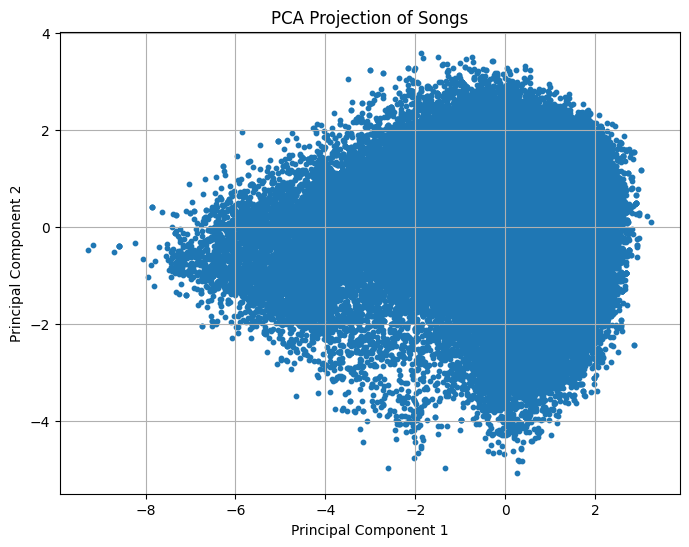

In [281]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=10            # حجم النقطة
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Songs")
plt.grid(True)
plt.show()

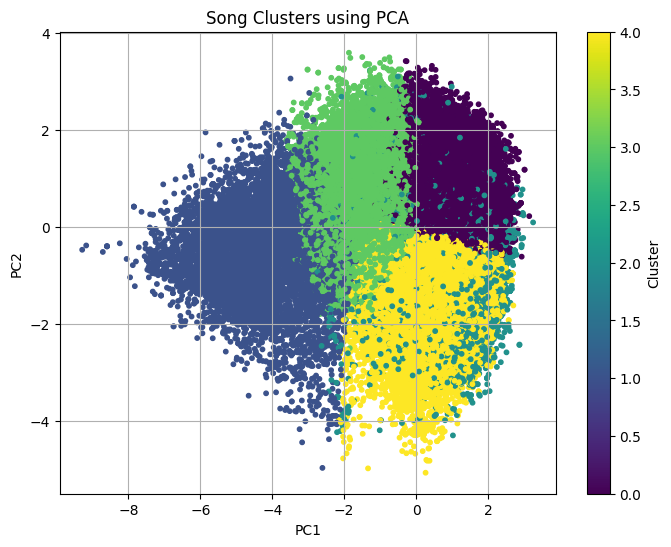

In [282]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(pca_df)
pca_df["Cluster"] = clusters

# show the result
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",  # ألوان أوضح
    s=10,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Song Clusters using PCA")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

Principal directions:

In [283]:
# 2 استخراج الـ Principal Directions (المكونات)

loadings = pd.DataFrame(
pca.components_.T,
columns=["PC1","PC2","PC3","PC4","PC5"],
index=features.columns # أسماء الأعمدة الأصلية
)

display(loadings)


,PC1,PC2,PC3,PC4,PC5
danceability,0.246124,0.574759,-0.087916,-0.297117,0.251589
energy,0.509168,-0.276668,-0.009548,-0.180383,-0.027775
loudness,0.516954,-0.078894,-0.057594,0.002617,-0.186764
speechiness,0.100641,0.026988,0.641281,-0.248258,0.544157
acousticness,-0.439341,0.296186,0.227289,0.308564,0.027705
instrumentalness,-0.282407,-0.305665,-0.201594,-0.496160,0.402351
liveness,0.085135,-0.232578,0.678626,0.089588,-0.250225
valence,0.295026,0.522029,0.021582,0.173981,0.087443
tempo,0.189047,-0.279982,-0.155955,0.661712,0.609944


Variance explanation:

In [284]:
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance: [0.31928144 0.15850939 0.13545804 0.10119368 0.09850895]
Total Variance: 0.8129514930988642


In [285]:
# 3. حساب التباين لكل اتجاه
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# تحويلها لجدول للتوضيح
variance_summary = pd.DataFrame({
    'Individual Variance (%)': explained_variance * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
}, index=[f'PC{i+1}' for i in range(len(explained_variance))])

print("Explained Variance Summary:")
display(variance_summary)


total_variance = sum(pca.explained_variance_ratio_) * 100
print(f"\nTotal Variance: {total_variance:.2f} %")

Explained Variance Summary:


,Individual Variance (%),Cumulative Variance (%)
PC1,31.928144,31.928144
PC2,15.850939,47.779082
PC3,13.545804,61.324886
PC4,10.119368,71.444254
PC5,9.850895,81.295149



Total Variance: 81.30 %


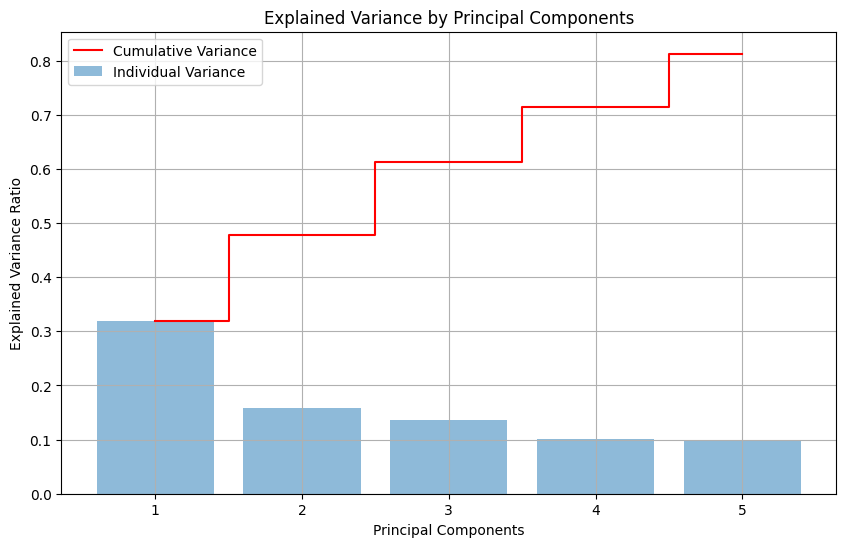


PC1: 31.93%
PC2: 15.85%
PC3: 13.55%
PC4: 10.12%
PC5: 9.85%


In [286]:
# حساب نسبة التباين لكل محور
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', label='Cumulative Variance', color='red')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid()
plt.show()

print()

# طباعة النتائج بالأرقام
for i, ratio in enumerate(explained_variance):
    print(f"PC{i+1}: {ratio:.2%}")